# Halo Properties

Using structured collections allows us to do more complicated analysis tasks with simulation particle data. To show what we mean, lets use a structured collection with halo properties and particles to do some comparisons between the properties of relaxed and unrelaxed halos.

We start, as always, by importing the packages we will need:

In [3]:
import opencosmo as oc
import numpy as np
import matplotlib.pyplot as plt

First, let's briefly recap what it means to be "relaxed" or "unrelaxed". A relaxed dark matter halo is a halo that is in virial equilibrium. As such, it is stable, in a sense: you won't see it contracting or expanding, and its density profile will be mostly smooth. Halos can become unrelaxed through violent events like mergers, which breaks virial equilibrium and creates substantial substructure in the halo.

The typical way to determine if a halo is relaxed or not, is to look at the offset between the halo center of mass ($r_{com}$) and the potential minimum of the halo ($r_{min}$). A virialized object will have a low offset because the most massive objects will settle in the center of the halo. Meanwhile, if a halo is unrelaxed due to a merger, the offset will be larger. The exact criteria to call a halo relaxed is as follows:

$$ 0.07 > \frac{||r_{min} - r_{com}||}{R_{200,c}}$$

Let's load some data, and separate it into a relaxed and unrelaxed dataset:

In [4]:
proppath = "/lustre/orion/hep142/proj-shared/INCITE/hydro/HDF5_data/run_hydro/output/step_624/haloproperties/m000p-624.haloproperties.0.hdf5"
partpath = "/lustre/orion/hep142/proj-shared/INCITE/hydro/HDF5_data/run_hydro/output/step_624/sodbighaloparticles/m000p-624.sodbighaloparticles.0.hdf5"
data = oc.open(proppath,partpath).take(5000)

First, we have to make a new column with the offset between $r_{min}$ and $r_{com}$. We can do this quickly by using `.with_new_columns()`. First, we tell opencosmo how to make the column, using `.col()` to refer to specific ones, and then we simply pass it to `.with_new_columns()`, making sure to specify the dataset we are looking at. Take a special note of how we give this column a name. There isn't an separtate argument we have to pass to `.with_new_columns()`, we just simply set the name we want equal to the column we just computed.

In [5]:
dist = np.sqrt((oc.col('fof_halo_center_x') - oc.col('fof_halo_com_x'))**2 + 
               (oc.col('fof_halo_center_y') - oc.col('fof_halo_com_y'))**2 + 
               (oc.col('fof_halo_center_z') - oc.col('fof_halo_com_z'))**2 ) #compute distance
dist = dist / oc.col('sod_halo_RVir') # divide by virial radius

data = data.with_new_columns(dataset="halo_properties", r_offset = dist) #r_offset becomes the name of the column.

> **Tip:**
>
> If the above process is too long and clunky for your tastes, you can instead import and use the `offset_3d` function. Try using it to recreate the above column as practice!

Now we can easily break up our data into two new datasets based on if they satisfy the above criteria. This involves two calls to `.filter()` to make two new datasets

In [6]:
d_relax = data.filter(oc.col('r_offset') < 0.07)
d_unrelax = data.filter(oc.col('r_offset') > 0.07)

Now let's make some plots! We can start with something more straightforward, and look at the mass of the halos. We can also print the fraction of relaxed objects to see if we are getting reasonable results. 
This plot will only require us to use a `.select()` column query on the halo_properties dataset. See how it is done below:

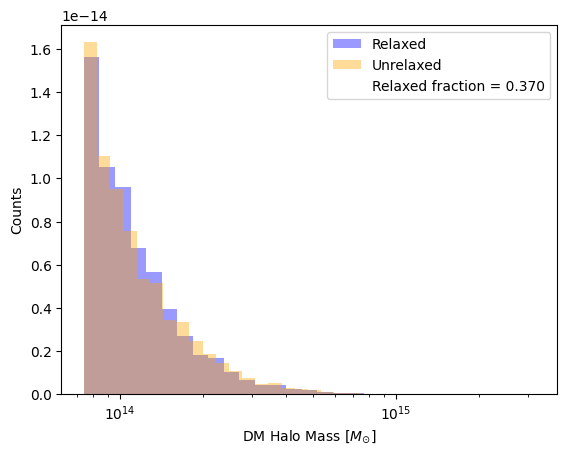

In [7]:
# fraction of relaxed halos
f = len(d_relax)/(len(d_unrelax) + len(d_relax))

# select desired column, and use .get_data() for an astropy array
M_rel = d_relax['halo_properties'].select('sod_halo_mass').get_data().value
M_unrel = d_unrelax['halo_properties'].select('sod_halo_mass').get_data().value

#plot
bins = np.logspace(np.min(np.log10(M_rel)),np.max(np.log10(M_rel)),30)
plt.hist(M_rel, bins = bins, alpha = 0.4, label = f'Relaxed', density = True, color = 'blue')
bins = np.logspace(np.min(np.log10(M_unrel)),np.max(np.log10(M_unrel)),30)
plt.hist(M_unrel, bins = bins, alpha = 0.4, label = f'Unrelaxed', density = True, color = 'orange')
plt.plot([], [], ' ', label=f"Relaxed fraction = {f:.3f}")
plt.xscale('log')
plt.xlabel('DM Halo Mass [$M_{\odot}$]')
plt.ylabel('Counts')
plt.legend()
plt.show()

Our mass distribution and relaxed halo fraction is in line with what we expect!

We aren't restricted to only halo properties when using a structured collection, we also have access to particle data. Let's use those particles to investigate the Brightest Cluster Galaxy (BCG). We expect the BCGs to have slightly different mass distributions based on the relaxation of the cluster. To show this, let's put a 50 kpc aperture around the potential minimum of the cluster and calculate the mass of that central galaxy using star particles.

Making a new column with the mass of the BCG will be a much more complicated task, so we will forgo using `.with_new_columns()` and instead use `.evaluate()`. The Evaluate function takes a function of the user's creation and can return the output of that function as a new column in the dataset. For structured datasets, the function should always have the properties and particles needed for the calaculation as input. Hence why our function below only has `halo_properties` and `star_particles` as input. From here you write the function as normal and return a dictionary, where the key will be used the name of the new columns.

In [8]:
#Mass distribution of CCG, relaxed v. unrelaxed
def Central_Mass(halo_properties, star_particles):
    pos = np.vstack((star_particles['x'],star_particles['y'],star_particles['z'])).T
    pmass = star_particles['mass']
    fof_cen = np.array([halo_properties['fof_halo_center_x'], halo_properties['fof_halo_center_y'], halo_properties['fof_halo_center_z']])
    
    dists = np.sqrt( np.sum((pos - fof_cen)**2, axis = 1) )
    mass = np.sum(pmass[dists < 0.05])
    return {'BCG_mass' : mass}

In our call to `.evaluate()` we need to make sure to specify what columns the function uses, the format of the data (numpy or astropy), and whether or not we want the column(s) inserted into the dataset. We set `insert = True` to make sure our new BCG mass column makes it into both datasets.

In [9]:
d_relax = d_relax.evaluate(Central_Mass, 
                            star_particles = ['x', 'y', 'z', 'mass'], 
                            halo_properties = ['fof_halo_center_x', 'fof_halo_center_y','fof_halo_center_z'], 
                            format = 'numpy', 
                            insert = True)

d_unrelax = d_unrelax.evaluate(Central_Mass, 
                            star_particles = ['x', 'y', 'z', 'mass'], 
                            halo_properties = ['fof_halo_center_x', 'fof_halo_center_y','fof_halo_center_z'], 
                            format = 'numpy', 
                            insert = True)

Now we can use that column just like any other, call `.select()` and `.get_data()` to extract the column data and plot.

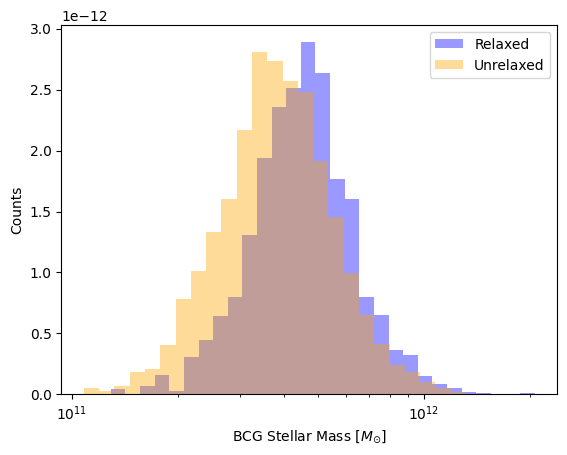

In [10]:
#extract columns
BCG_rel = d_relax['halo_properties'].select('BCG_mass').get_data()
BCG_unrel = d_unrelax['halo_properties'].select('BCG_mass').get_data()

#plot
bins = np.logspace(np.min(np.log10(BCG_rel)),np.max(np.log10(BCG_rel)),30)
plt.hist(BCG_rel, bins = bins, alpha = 0.4, label = 'Relaxed', density = True, color = 'blue')
bins = np.logspace(np.min(np.log10(BCG_unrel)),np.max(np.log10(BCG_unrel)),30)
plt.hist(BCG_unrel, bins = bins, alpha = 0.4, label = 'Unrelaxed', density = True, color = 'orange')

plt.xscale('log')
plt.xlabel('BCG Stellar Mass [$M_{\odot}$]')
plt.ylabel('Counts')
plt.legend()
plt.show()

Notice how the mass distribution of BCGs in unrelaxed halos is peaked at a slighly lower stellar mass! We can even take this a step further and plot the Stellar Mass - Halo Mass relation for these BCGs. We have all the data we need, so we just need to plot it:

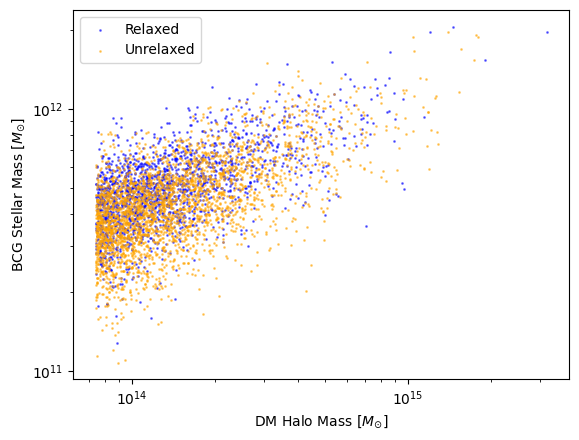

In [11]:
plt.scatter(M_rel, BCG_rel, label = 'Relaxed', color = 'blue', s = 1, alpha = 0.5)
plt.scatter(M_unrel, BCG_unrel, label = 'Unrelaxed', color = 'orange', s = 1, alpha = 0.5)
plt.ylabel('BCG Stellar Mass [$M_{\odot}$]')
plt.xlabel('DM Halo Mass [$M_{\odot}$]')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

For our final plots, we can incorporate gas particles by looking at the bulk motion of stars compared to gas in the BCG. While we are at it, we can also compute the BCG velocity dispersion.

To make these columns we call `.evaluate()` as before, but now we also provide `gas_particles` as an input for the function and specify the columns we need for our calculation. Note also how our dictionary now has 4 entries, since we want to add 4 columns to our dataset. Once again, the name of each column will be the key of each dictionary entry.

In [12]:
#This cell may take a while to run, multiple minutes!
def Central_V(halo_properties, star_particles, gas_particles):
    #get required quantities
    pos = np.vstack((star_particles['x'],star_particles['y'],star_particles['z'])).T
    vel = np.vstack((star_particles['vx'],star_particles['vy'],star_particles['vz'])).T
    fof_cen = np.array([halo_properties['fof_halo_center_x'], halo_properties['fof_halo_center_y'], halo_properties['fof_halo_center_z']])
    pmass = star_particles['mass']
    
    #make BCG mask
    dists = np.sqrt( np.sum((pos - fof_cen)**2, axis = 1) )
    mask = dists <= 0.05
    
    #mass weighted velocity dispersion and mean motion
    vm_stars = np.average(vel[mask], axis = 0, weights = pmass[mask])
    vd = np.average((vel[mask] - vm_stars)**2, axis = 0, weights = pmass[mask])
    vd_stars = np.sqrt(np.sum(vd))
    
    #repeat for gas
    pos = np.vstack((gas_particles['x'],gas_particles['y'],gas_particles['z'])).T
    vel = np.vstack((gas_particles['vx'],gas_particles['vy'],gas_particles['vz'])).T
    pmass = gas_particles['mass']
    
    dists = np.sqrt( np.sum((pos - fof_cen)**2, axis = 1) )
    mask = dists <= 0.05
    
    vm_gas = np.average(vel[mask], axis = 0, weights = pmass[mask])
    vd = np.average((vel[mask] - vm_stars)**2, axis = 0, weights = pmass[mask])
    vd_gas = np.sqrt(np.sum(vd))
    
    return {'vm_stars' : vm_stars, 'vd_stars' : vd_stars, 'vm_gas' : vm_gas, 'vd_gas' : vd_gas}

d_relax = d_relax.evaluate(Central_V, 
                            star_particles = ['x', 'y', 'z', 'mass', 'vx', 'vy', 'vz'], 
                            gas_particles = ['x', 'y', 'z', 'mass', 'vx', 'vy', 'vz'],
                            halo_properties = ['fof_halo_center_x', 'fof_halo_center_y','fof_halo_center_z'], 
                            format = 'numpy', 
                            insert = True)

d_unrelax = d_unrelax.evaluate(Central_V, 
                            star_particles = ['x', 'y', 'z', 'mass', 'vx', 'vy', 'vz'], 
                            gas_particles = ['x', 'y', 'z', 'mass', 'vx', 'vy', 'vz'],
                            halo_properties = ['fof_halo_center_x', 'fof_halo_center_y','fof_halo_center_z'], 
                            format = 'numpy', 
                            insert = True)

Now we plot the columns as normal. Let's look at the stellar velocity dispersion as a function of mass first.

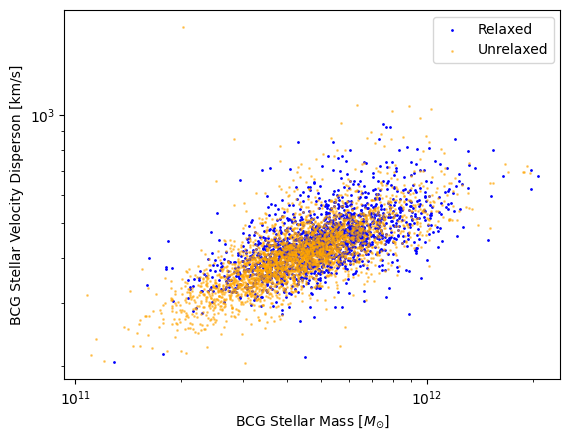

In [13]:
#select columns...
vd_rel = d_relax['halo_properties'].select('vd_stars').get_data()
vd_unrel = d_unrelax['halo_properties'].select('vd_stars').get_data()

#and plot!
plt.scatter(BCG_rel, vd_rel, label = 'Relaxed', color = 'blue', s = 1)
plt.scatter(BCG_unrel, vd_unrel, label = 'Unrelaxed', color = 'orange', s = 1, alpha = 0.5)
plt.ylabel('BCG Stellar Velocity Disperson [km/s]')
plt.xlabel('BCG Stellar Mass [$M_{\odot}$]')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

As expected, we get a steady increase in velocity dispersion as mass increases! 

> **What about the gas velocity dispersion?**
>
> Above we only plotted the stellar velocity dispersion. Can you change the code above to show the same plot but for the gas? Try to also make a plot comparing the gas and stellar velocity dispersions to each other.

Now let's compare the bulk velocity between gas and star particles. Plots like these can help us identify highly disturbed galaxy clusters. The red line is the 1-to-1 line, where the gas and stars are moving with similar bulk velocities.

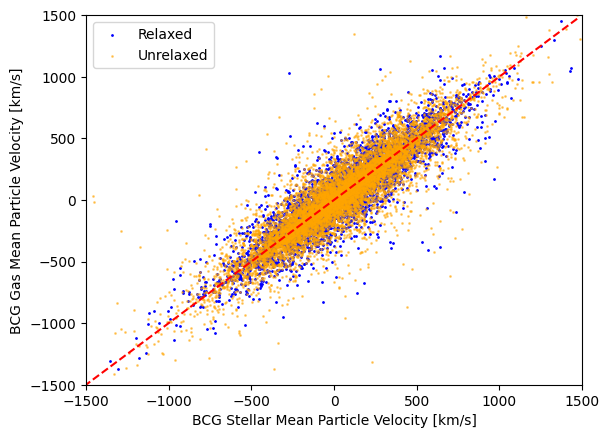

In [14]:
#select gas/star bulk velocity offsets...
vms_rel  = d_relax['halo_properties'].select('vm_stars').get_data()
vms_unrel = d_unrelax['halo_properties'].select('vm_stars').get_data()
vmg_rel  = d_relax['halo_properties'].select('vm_gas').get_data()
vmg_unrel = d_unrelax['halo_properties'].select('vm_gas').get_data()

#plot!
plt.scatter(vms_rel, vmg_rel, label = 'Relaxed', color = 'blue', s = 1)
plt.scatter(vms_unrel, vmg_unrel, label = 'Unrelaxed', color = 'orange', s = 1, alpha = 0.5)
plt.plot([vms_unrel.min(),vms_unrel.max()], [vms_unrel.min(),vms_unrel.max()], linestyle = 'dashed', color = 'r')
plt.xlabel('BCG Stellar Mean Particle Velocity [km/s]')
plt.ylabel('BCG Gas Mean Particle Velocity [km/s]')
plt.xlim(-1500,1500)
plt.ylim(-1500,1500)
plt.legend()
plt.show()

As we can see, many galaxies lie close to the 1-to-1 line, but the scatter indicates clusters that are more likely to be disturbed.